In [1]:
# ─────────────────────────────────────────────────────────────
# CELL 1 — Imports and Connections
# ─────────────────────────────────────────────────────────────

import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import requests
from catboost import CatBoostRegressor
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import os
from sklearn.metrics import mean_absolute_error, root_mean_squared_error

In [2]:
# ─────────────────────────────────────────────────────────────
# CELL 2 — Load Local Inverter Data from CSV
# ─────────────────────────────────────────────────────────────

# Update path to where your CSV is saved on your laptop
csv_path = "D:\Desktop\ESSCO\essco-ai\Dataset\TKKHEAD01\semply_cloud.meter.solar.1.csv" 

df_inverter = pd.read_csv(csv_path)

# 1. Standardize column mapping (Ensuring 'timestamp' and 'ac_power_total')
# If your CSV uses a different timestamp column name (like 'time' or 'date'), update it on the right side below:
df_inverter = df_inverter.rename(columns={
    "dateTime": "timestamp",   # Replace "time" if your column name is different
    "pTot": "ac_power_total"
})

# 2. Keep only required columns and remove missing records
keep_cols = ["timestamp", "ac_power_total"]
df_inverter = df_inverter[keep_cols].dropna(subset=["ac_power_total"])

print(f"✅ Inverter CSV data loaded → shape: {df_inverter.shape}")
print(f"   Date range: {df_inverter['timestamp'].min()}  →  {df_inverter['timestamp'].max()}\n")
df_inverter.head(3)

✅ Inverter CSV data loaded → shape: (316922, 2)
   Date range: 2025-11-08T03:46:23.000Z  →  2026-06-19T12:54:01.000Z



,timestamp,ac_power_total
0,2026-06-19T12:54:01.000Z,23.20
1,2026-06-19T12:53:01.000Z,17.22
2,2026-06-19T12:52:01.000Z,22.10


In [3]:
# ─────────────────────────────────────────────────────────────
# CELL 3 — Fetch Weather Data via Open-Meteo API
# ─────────────────────────────────────────────────────────────

# 1. Automatically match the time range of your historical CSV
start_date = pd.to_datetime(df_inverter['timestamp'].min()).strftime('%Y-%m-%d')
end_date = pd.to_datetime(df_inverter['timestamp'].max()).strftime('%Y-%m-%d')

# 2. Configure Open-Meteo API parameters (Using Archive API for historical periods)
# Replace latitude and longitude with your site's coordinates if needed
latitude = 13.7275   
longitude = 100.7781 

url = "https://archive-api.open-meteo.com/v1/archive"
params = {
    "latitude": latitude,
    "longitude": longitude,
    "start_date": start_date,
    "end_date": end_date,
    "hourly": "direct_radiation,cloud_cover",  # direct_radiation maps closely to solar_irradiance
    "timezone": "UTC"
}

print(f"🌐 Fetching Open-Meteo historical weather from {start_date} to {end_date}...")
response = requests.get(url, params=params).json()

# 3. Parse hourly data into your traditional df_weather format
hourly_data = response["hourly"]

df_weather = pd.DataFrame({
    "timestamp": hourly_data["time"],
    "solar_irradiance": hourly_data["direct_radiation"],  # Mapped to your old feature name
    "cloud_cover": hourly_data["cloud_cover"]
})

# Clean and drop any missing records
df_weather = df_weather.dropna(subset=["solar_irradiance", "cloud_cover"])

print(f"✅ Open-Meteo Weather data loaded → shape: {df_weather.shape}")
print(f"   Date range: {df_weather['timestamp'].min()}  →  {df_weather['timestamp'].max()}")
df_weather.head(3)
df_weather.shape

🌐 Fetching Open-Meteo historical weather from 2025-11-08 to 2026-06-19...
✅ Open-Meteo Weather data loaded → shape: (5376, 3)
   Date range: 2025-11-08T00:00  →  2026-06-19T23:00


(5376, 3)

In [4]:
# ─────────────────────────────────────────────────────────────
# CELL 4 — Fetch Historical Forecast Data (Open-Meteo)
# ─────────────────────────────────────────────────────────────

# ── Site coordinates ──────────────────────────────────────────
LATITUDE  = 14.066094225657675  
LONGITUDE = 100.63597818535003  

# ✅ FIX: Safely parse the timestamp column directly from CELL 2's dataframe
start_date = pd.to_datetime(df_inverter['timestamp'].min()).normalize()
end_date   = pd.to_datetime(df_inverter['timestamp'].max()).normalize()

params = {
    "latitude"  : LATITUDE,
    "longitude" : LONGITUDE,
    "start_date": start_date.strftime("%Y-%m-%d"),
    "end_date"  : end_date.strftime("%Y-%m-%d"),
    "hourly"    : [
        "cloud_cover",
        "shortwave_radiation",
    ],
    "timezone"  : "UTC",
}

# (The rest of your logic remains completely untouched and works perfectly)
resp = requests.get(
    "https://historical-forecast-api.open-meteo.com/v1/forecast",
    params=params,
    timeout=60,
)
resp.raise_for_status()
json_data = resp.json()

# Parse hourly data
hourly = json_data["hourly"]
df_forecast = pd.DataFrame({
    "timestamp"                  : pd.to_datetime(hourly["time"]),
    "cloud_cover_forecast_1h"    : hourly["cloud_cover"],
    "solar_irradiance_forecast_1h": hourly["shortwave_radiation"],
})

# Ensure timestamps are UTC-aware
df_forecast["timestamp"] = df_forecast["timestamp"].dt.tz_localize("UTC")

print(f"✅ Open-Meteo forecast data fetched → shape: {df_forecast.shape}")
print(f"   Date range: {df_forecast['timestamp'].min()}  →  {df_forecast['timestamp'].max()}")
df_forecast

✅ Open-Meteo forecast data fetched → shape: (5376, 3)
   Date range: 2025-11-08 00:00:00+00:00  →  2026-06-19 23:00:00+00:00


,timestamp,cloud_cover_forecast_1h,solar_irradiance_forecast_1h
0,2025-11-08 00:00:00+00:00,86,15.0
1,2025-11-08 01:00:00+00:00,100,122.0
2,2025-11-08 02:00:00+00:00,52,296.0
3,2025-11-08 03:00:00+00:00,87,541.0
4,2025-11-08 04:00:00+00:00,100,450.0
...,...,...,...
5371,2026-06-19 19:00:00+00:00,100,0.0
5372,2026-06-19 20:00:00+00:00,100,0.0
5373,2026-06-19 21:00:00+00:00,100,0.0
5374,2026-06-19 22:00:00+00:00,100,0.0


In [5]:
df_inverter.head(5)

,timestamp,ac_power_total
0,2026-06-19T12:54:01.000Z,23.20
1,2026-06-19T12:53:01.000Z,17.22
2,2026-06-19T12:52:01.000Z,22.10
3,2026-06-19T12:51:01.000Z,20.36
4,2026-06-19T12:50:01.000Z,21.28


In [6]:
df_inverter.shape

(316922, 2)

In [7]:
# ─────────────────────────────────────────────────────────────
# CELL 5 — Resample All Sources to 5-Minute Grid
# ─────────────────────────────────────────────────────────────

def to_utc_index(df: pd.DataFrame, ts_col: str = "timestamp") -> pd.DataFrame:
    """Convert a timestamp column to a UTC-aware DatetimeIndex."""
    df = df.copy()
    df[ts_col] = pd.to_datetime(df[ts_col])
    if df[ts_col].dt.tz is None:
        df[ts_col] = df[ts_col].dt.tz_localize("UTC")
    else:
        df[ts_col] = df[ts_col].dt.tz_convert("UTC")
    df = df.set_index(ts_col).sort_index()
    return df

# ── 1. Inverter (CSV) — 5-min mean from 'pTot' ─────────────────
df_inverter = to_utc_index(df_inverter)
df_inverter = df_inverter.resample("5min").mean()
print(f"✅ df_inverter  resampled → {df_inverter.shape}")

# ── 2. Weather (Keep or skip if also embedded in your CSV) ─────
df_weather = to_utc_index(df_weather)
df_weather = df_weather.resample("5min").mean().interpolate(method="time")
print(f"✅ df_weather   resampled → {df_weather.shape}")

# ── 3. Forecast — 5-min time interpolation (hourly → 5-min) ───
df_forecast = to_utc_index(df_forecast)
df_forecast = df_forecast.resample("5min").interpolate(method="time")
print(f"✅ df_forecast  resampled → {df_forecast.shape}")

print("\n📋 All sources aligned to 5-minute UTC grid")

✅ df_inverter  resampled → (64334, 1)
✅ df_weather   resampled → (64501, 2)
✅ df_forecast  resampled → (64501, 2)

📋 All sources aligned to 5-minute UTC grid


In [8]:
df_inverter.head(3)

,ac_power_total
timestamp,
2025-11-08 03:45:00+00:00,104961.180
2025-11-08 03:50:00+00:00,150498.594
2025-11-08 03:55:00+00:00,77198.770


In [9]:
df_inverter.shape

(64334, 1)

In [10]:
# ─────────────────────────────────────────────────────────────
# CELL 6 — Join All Data Sources (Inner Join)
# ─────────────────────────────────────────────────────────────

# Inner join on the shared UTC DatetimeIndex
df = (
    df_inverter
    .join(df_weather,  how="inner")
    .join(df_forecast, how="inner")
)

print(f"✅ Joined dataset → shape: {df.shape}")
print(f"   Date range: {df.index.min()}  →  {df.index.max()}")
print(f"   Columns: {list(df.columns)}")
df.shape

✅ Joined dataset → shape: (64334, 5)
   Date range: 2025-11-08 03:45:00+00:00  →  2026-06-19 12:50:00+00:00
   Columns: ['ac_power_total', 'solar_irradiance', 'cloud_cover', 'cloud_cover_forecast_1h', 'solar_irradiance_forecast_1h']


(64334, 5)

In [11]:
df.head(3)

,ac_power_total,solar_irradiance,cloud_cover,cloud_cover_forecast_1h,solar_irradiance_forecast_1h
timestamp,,,,,
2025-11-08 03:45:00+00:00,104961.180,123.25,100.0,96.750000,472.750000
2025-11-08 03:50:00+00:00,150498.594,109.50,100.0,97.833333,465.166667
2025-11-08 03:55:00+00:00,77198.770,95.75,100.0,98.916667,457.583333


In [12]:
# ─────────────────────────────────────────────────────────────
# CELL 8 — Reindex Grid & Create Lag Features
# ─────────────────────────────────────────────────────────────

# 1. Create a perfectly unbroken 5-minute timeline from start to end
full_time_index = pd.date_range(start=df.index.min(), end=df.index.max(), freq="5min", tz="UTC")

# 2. Reindex the dataframe so all missing night-time rows are explicitly added
df = df.reindex(full_time_index)

# 3. Safely fill missing night values for solar power with 0
df["ac_power_total"] = df["ac_power_total"].fillna(0)

# 4. Forward-fill weather/forecast data gaps if any exist over night
df["solar_irradiance"] = df["solar_irradiance"].ffill().bfill()
df["cloud_cover"] = df["cloud_cover"].ffill().bfill()
df["cloud_cover_forecast_1h"] = df["cloud_cover_forecast_1h"].ffill().bfill()
df["solar_irradiance_forecast_1h"] = df["solar_irradiance_forecast_1h"].ffill().bfill()

# 5. Now create your Lag Features safely!
# Only use lags that are at least as far back as your prediction target window
LAG_STEPS = [12, 24, 36, 288]  # 1 hour ago, 2 hours ago, 3 hours ago, 24 hours ago

for lag in LAG_STEPS:
    df[f"lag_{lag}"] = df["ac_power_total"].shift(lag)

print(f"✅ Grid complete. Lag features created: {[f'lag_{l}' for l in LAG_STEPS]}")
df[["ac_power_total"] + [f"lag_{l}" for l in LAG_STEPS]].head(15)

✅ Grid complete. Lag features created: ['lag_12', 'lag_24', 'lag_36', 'lag_288']


,ac_power_total,lag_12,lag_24,lag_36,lag_288
2025-11-08 03:45:00+00:00,104961.180000,NaN,NaN,NaN,NaN
2025-11-08 03:50:00+00:00,150498.594000,NaN,NaN,NaN,NaN
2025-11-08 03:55:00+00:00,77198.770000,NaN,NaN,NaN,NaN
2025-11-08 04:00:00+00:00,45190.353750,NaN,NaN,NaN,NaN
2025-11-08 04:05:00+00:00,65519.866000,NaN,NaN,NaN,NaN
2025-11-08 04:10:00+00:00,139367.930000,NaN,NaN,NaN,NaN
2025-11-08 04:15:00+00:00,208132.246000,NaN,NaN,NaN,NaN
2025-11-08 04:20:00+00:00,108884.698000,NaN,NaN,NaN,NaN
2025-11-08 04:25:00+00:00,72512.762000,NaN,NaN,NaN,NaN
2025-11-08 04:30:00+00:00,64166.088000,NaN,NaN,NaN,NaN


In [13]:
df.shape

(64334, 9)

In [14]:
# ─────────────────────────────────────────────────────────────
# CELL 9 — Create Rolling Features
# ─────────────────────────────────────────────────────────────

WINDOW = 6

df["rolling_mean_6"] = df["ac_power_total"].rolling(window=WINDOW).mean()
df["rolling_std_6"]  = df["ac_power_total"].rolling(window=WINDOW).std()
df["rolling_mean_12"] = df["ac_power_total"].rolling(window=12).mean()
df["rolling_mean_24"] = df["ac_power_total"].rolling(window=24).mean()

print(f"✅ Rolling features created: rolling_mean_6, rolling_std_6, rolling_mean_12, rolling_mean_24")
df[["ac_power_total", "rolling_mean_6", "rolling_std_6", "rolling_mean_12", "rolling_mean_24"]].head(10)

✅ Rolling features created: rolling_mean_6, rolling_std_6, rolling_mean_12, rolling_mean_24


,ac_power_total,rolling_mean_6,rolling_std_6,rolling_mean_12,rolling_mean_24
2025-11-08 03:45:00+00:00,104961.18000,NaN,NaN,NaN,NaN
2025-11-08 03:50:00+00:00,150498.59400,NaN,NaN,NaN,NaN
2025-11-08 03:55:00+00:00,77198.77000,NaN,NaN,NaN,NaN
2025-11-08 04:00:00+00:00,45190.35375,NaN,NaN,NaN,NaN
2025-11-08 04:05:00+00:00,65519.86600,NaN,NaN,NaN,NaN
2025-11-08 04:10:00+00:00,139367.93000,97122.782292,41923.162994,NaN,NaN
2025-11-08 04:15:00+00:00,208132.24600,114317.959958,62089.248218,NaN,NaN
2025-11-08 04:20:00+00:00,108884.69800,107382.310625,59510.060305,NaN,NaN
2025-11-08 04:25:00+00:00,72512.76200,106601.309292,60014.024870,NaN,NaN
2025-11-08 04:30:00+00:00,64166.08800,109763.931667,56529.364704,NaN,NaN


In [15]:
# ─────────────────────────────────────────────────────────────
# CELL 10 — Create Time Features (Asia/Bangkok)
# ─────────────────────────────────────────────────────────────

LOCAL_TZ = "Asia/Bangkok"

local_index = df.index.tz_convert(LOCAL_TZ)

hour_of_day = local_index.hour + local_index.minute / 60.0
df["hour_sin"] = np.sin(2 * np.pi * hour_of_day / 24.0)
df["hour_cos"] = np.cos(2 * np.pi * hour_of_day / 24.0)
df["day_of_week"] = local_index.dayofweek   # Monday=0, Sunday=6

print(f"✅ Time features created (timezone: {LOCAL_TZ})")
print(f"   hour_sin/hour_cos cyclical encoding applied.")
print(f"   day_of_week → unique values: {sorted(df['day_of_week'].unique())}")
df[["hour_sin", "hour_cos", "day_of_week"]].head(5)

✅ Time features created (timezone: Asia/Bangkok)
   hour_sin/hour_cos cyclical encoding applied.
   day_of_week → unique values: [0, 1, 2, 3, 4, 5, 6]


,hour_sin,hour_cos,day_of_week
2025-11-08 03:45:00+00:00,0.321439,-0.946930,5
2025-11-08 03:50:00+00:00,0.300706,-0.953717,5
2025-11-08 03:55:00+00:00,0.279829,-0.960050,5
2025-11-08 04:00:00+00:00,0.258819,-0.965926,5
2025-11-08 04:05:00+00:00,0.237686,-0.971342,5


In [16]:
# ─────────────────────────────────────────────────────────────
# CELL 11 — Create Target Variable
# ─────────────────────────────────────────────────────────────

# 12 steps × 5 minutes = 60 minutes ahead
TARGET_SHIFT = 12

df["target_solar_1h"] = df["ac_power_total"].shift(-TARGET_SHIFT)

print(f"✅ Target created: target_solar_1h = ac_power_total.shift(-{TARGET_SHIFT})")
print(f"   Non-null target values: {df['target_solar_1h'].notna().sum()} / {len(df)}")
df[["ac_power_total", "target_solar_1h"]].head(20)

✅ Target created: target_solar_1h = ac_power_total.shift(-12)
   Non-null target values: 64322 / 64334


,ac_power_total,target_solar_1h
2025-11-08 03:45:00+00:00,104961.180000,61320.378000
2025-11-08 03:50:00+00:00,150498.594000,79948.385000
2025-11-08 03:55:00+00:00,77198.770000,98037.491667
2025-11-08 04:00:00+00:00,45190.353750,54289.265714
2025-11-08 04:05:00+00:00,65519.866000,62525.594000
2025-11-08 04:10:00+00:00,139367.930000,110765.308000
2025-11-08 04:15:00+00:00,208132.246000,127159.597500
2025-11-08 04:20:00+00:00,108884.698000,148811.901429
2025-11-08 04:25:00+00:00,72512.762000,154238.628000
2025-11-08 04:30:00+00:00,64166.088000,140283.870000


In [17]:
# ─────────────────────────────────────────────────────────────
# CELL 12 — Remove NaN Rows
# ─────────────────────────────────────────────────────────────

shape_before = df.shape
print(f"Shape BEFORE dropping NaNs: {shape_before}")

df = df.dropna()

shape_after = df.shape
print(f"Shape AFTER  dropping NaNs: {shape_after}")
print(f"Rows removed: {shape_before[0] - shape_after[0]}")
print()
print("Remaining NaN counts per column:")
print(df.isnull().sum())

Shape BEFORE dropping NaNs: (64334, 17)
Shape AFTER  dropping NaNs: (64034, 17)
Rows removed: 300

Remaining NaN counts per column:
ac_power_total                  0
solar_irradiance                0
cloud_cover                     0
cloud_cover_forecast_1h         0
solar_irradiance_forecast_1h    0
lag_12                          0
lag_24                          0
lag_36                          0
lag_288                         0
rolling_mean_6                  0
rolling_std_6                   0
rolling_mean_12                 0
rolling_mean_24                 0
hour_sin                        0
hour_cos                        0
day_of_week                     0
target_solar_1h                 0
dtype: int64


In [18]:
df.shape

(64034, 17)

df.shape   : (64034, 17)

── dtypes ──────────────────────────────────
ac_power_total                  float64
solar_irradiance                float64
cloud_cover                     float64
cloud_cover_forecast_1h         float64
solar_irradiance_forecast_1h    float64
lag_12                          float64
lag_24                          float64
lag_36                          float64
lag_288                         float64
rolling_mean_6                  float64
rolling_std_6                   float64
rolling_mean_12                 float64
rolling_mean_24                 float64
hour_sin                        float64
hour_cos                        float64
day_of_week                       int32
target_solar_1h                 float64
dtype: object

── describe ────────────────────────────────


,ac_power_total,solar_irradiance,cloud_cover,cloud_cover_forecast_1h,solar_irradiance_forecast_1h,lag_12,lag_24,lag_36,lag_288,rolling_mean_6,rolling_std_6,rolling_mean_12,rolling_mean_24,hour_sin,hour_cos,day_of_week,target_solar_1h
count,64034.000000,64034.000000,64034.000000,64034.000000,64034.000000,64034.000000,64034.000000,64034.000000,64034.000000,64034.000000,64034.000000,64034.000000,64034.000000,64034.000000,6.403400e+04,64034.000000,64034.000000
mean,65361.746689,166.422954,51.139957,50.422511,232.142631,65373.141536,65386.075279,65391.091801,65400.281691,65363.456412,10684.212053,65366.413438,65372.658437,-0.000838,-9.346082e-04,2.984008,65338.388190
std,94376.031583,232.274912,39.643681,39.798553,300.747358,94373.121630,94371.523217,94373.078008,94376.684288,92100.537316,19871.623384,90967.565319,88857.281569,0.707089,7.071349e-01,1.998147,94373.481737
min,-440.540000,0.000000,0.000000,0.000000,0.000000,-440.540000,-440.540000,-440.540000,-440.540000,-83.112778,0.000000,-30.960472,-7.396583,-1.000000,-1.000000e+00,0.000000,-440.540000
25%,20.502000,0.000000,10.333333,9.520833,0.000000,20.502000,20.502000,20.502000,20.516000,20.584167,0.621384,20.660934,20.794868,-0.707107,-7.071068e-01,1.000000,20.500000
50%,30.074000,5.833333,47.666667,46.250000,17.916667,30.075000,30.075000,30.075000,30.178000,227.624000,443.191965,1322.948189,5015.971376,0.000000,-1.836970e-16,3.000000,30.059000
75%,121215.157679,327.229167,96.000000,95.833333,481.833333,121215.157679,121228.529000,121232.769000,121332.735000,125244.634194,12238.412104,126182.994507,127881.594860,0.707107,7.071068e-01,5.000000,121181.270000
max,376500.085000,849.000000,100.000000,100.000000,982.000000,376500.085000,376500.085000,376500.085000,376500.085000,337186.505222,196837.551926,331447.033702,327776.445289,1.000000,1.000000e+00,6.000000,376500.085000



── null counts ─────────────────────────────
ac_power_total                  0
solar_irradiance                0
cloud_cover                     0
cloud_cover_forecast_1h         0
solar_irradiance_forecast_1h    0
lag_12                          0
lag_24                          0
lag_36                          0
lag_288                         0
rolling_mean_6                  0
rolling_std_6                   0
rolling_mean_12                 0
rolling_mean_24                 0
hour_sin                        0
hour_cos                        0
day_of_week                     0
target_solar_1h                 0
dtype: int64


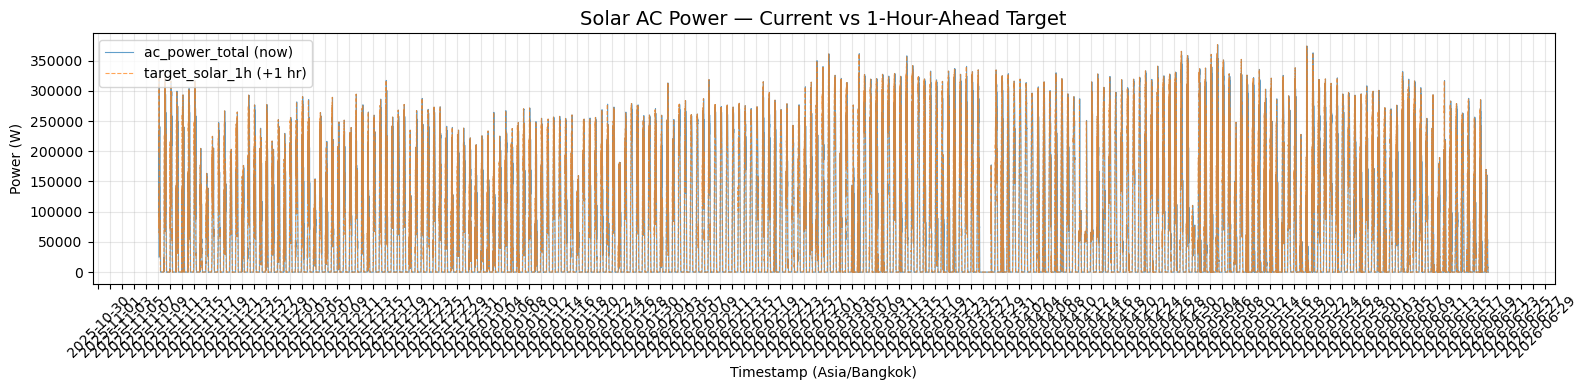

In [19]:
# ─────────────────────────────────────────────────────────────
# CELL 13 — Exploratory Validation
# ─────────────────────────────────────────────────────────────

print("=" * 60)
print(f"df.shape   : {df.shape}")
print("=" * 60)

print("\n── dtypes ──────────────────────────────────")
print(df.dtypes)

print("\n── describe ────────────────────────────────")
display(df.describe())

print("\n── null counts ─────────────────────────────")
print(df.isnull().sum())

# ── Plot ac_power_total vs target_solar_1h ────────────────────
fig, ax = plt.subplots(figsize=(16, 4))

# Convert to Bangkok time for the plot axis
local_ts = df.index.tz_convert("Asia/Bangkok")

ax.plot(local_ts, df["ac_power_total"],   label="ac_power_total (now)",    alpha=0.7, linewidth=0.8)
ax.plot(local_ts, df["target_solar_1h"],  label="target_solar_1h (+1 hr)", alpha=0.7, linewidth=0.8, linestyle="--")

ax.set_title("Solar AC Power — Current vs 1-Hour-Ahead Target", fontsize=14)
ax.set_xlabel("Timestamp (Asia/Bangkok)")
ax.set_ylabel("Power (W)")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
ax.xaxis.set_major_locator(mdates.DayLocator(interval=2))
plt.xticks(rotation=45)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [20]:
# ─────────────────────────────────────────────────────────────
# CELL 14 — Train / Validation Split (Chronological)
# ─────────────────────────────────────────────────────────────

FEATURES = [
    # Current solar signal
    "ac_power_total",
    # Lag features
    "lag_12", "lag_24", "lag_36", "lag_288",
    # Rolling features
    "rolling_mean_6", "rolling_std_6", "rolling_mean_12", "rolling_mean_24",
    # Current weather observations
    "solar_irradiance", "cloud_cover",
    # Forecast weather
    "solar_irradiance_forecast_1h", "cloud_cover_forecast_1h",
    # Time features
    "hour_sin", "hour_cos", "day_of_week",
]

TARGET = "target_solar_1h"

# Chronological 80/20 split — no shuffling
split_idx = int(len(df) * 0.8)

df_train = df.iloc[:split_idx]
df_val   = df.iloc[split_idx:]

X_train = df_train[FEATURES]
y_train = df_train[TARGET]
X_val   = df_val[FEATURES]
y_val   = df_val[TARGET]

print(f"Total rows   : {len(df):,}")
print(f"Train rows   : {len(df_train):,}  ({len(df_train)/len(df)*100:.1f}%)")
print(f"Val rows     : {len(df_val):,}  ({len(df_val)/len(df)*100:.1f}%)")
print(f"Feature count: {len(FEATURES)}")
print(f"Features     : {FEATURES}")

df_train.head(3)

Total rows   : 64,034
Train rows   : 51,227  (80.0%)
Val rows     : 12,807  (20.0%)
Feature count: 16
Features     : ['ac_power_total', 'lag_12', 'lag_24', 'lag_36', 'lag_288', 'rolling_mean_6', 'rolling_std_6', 'rolling_mean_12', 'rolling_mean_24', 'solar_irradiance', 'cloud_cover', 'solar_irradiance_forecast_1h', 'cloud_cover_forecast_1h', 'hour_sin', 'hour_cos', 'day_of_week']


,ac_power_total,solar_irradiance,cloud_cover,cloud_cover_forecast_1h,solar_irradiance_forecast_1h,lag_12,lag_24,lag_36,lag_288,rolling_mean_6,rolling_std_6,rolling_mean_12,rolling_mean_24,hour_sin,hour_cos,day_of_week,target_solar_1h
2025-11-09 03:45:00+00:00,24872.272,498.000000,80.000000,91.000000,650.75,61902.598,125717.000,4535.428,104961.180,49996.503806,32604.272318,61218.645403,69317.977326,0.321439,-0.946930,6,197052.4775
2025-11-09 03:50:00+00:00,110559.686,505.666667,81.333333,93.333333,662.50,102223.402,95582.470,17044.246,150498.594,49914.762472,32420.691093,61913.335736,69942.027993,0.300706,-0.953717,6,323453.0125
2025-11-09 03:55:00+00:00,89033.074,513.333333,82.666667,95.666667,674.25,63536.584,79712.094,18851.126,77198.770,58488.353556,35193.315976,64038.043236,70330.402160,0.279829,-0.960050,6,302895.9400


In [21]:
print("Maximum solar power in dataset:", df["ac_power_total"].max())

Maximum solar power in dataset: 376500.08499999996


In [22]:
# ─────────────────────────────────────────────────────────────
# CELL 15 — Train CatBoost Model
# ─────────────────────────────────────────────────────────────

params = {
    "loss_function": "RMSE",
    "learning_rate": 0.05,
    "depth": 8,
    "iterations": 1000,
    "random_seed": 42,
}

model = CatBoostRegressor(**params)

model.fit(
    X_train,
    y_train,
    eval_set=(X_val, y_val),
    early_stopping_rounds=50,
    verbose=50,
)

print("\n✅ Training complete")
print(f"Best iteration : {model.get_best_iteration()}")

0:	learn: 90211.6020454	test: 91572.5867253	best: 91572.5867253 (0)	total: 124ms	remaining: 2m 4s
50:	learn: 31415.3412830	test: 44944.9322434	best: 44944.9322434 (50)	total: 649ms	remaining: 12.1s
100:	learn: 28350.5013553	test: 44695.5505076	best: 44580.0289902 (72)	total: 1.17s	remaining: 10.5s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 44580.02899
bestIteration = 72

Shrink model to first 73 iterations.

✅ Training complete
Best iteration : 72


  Validation Metrics (Solar Power)
  RMSE : 44,580.03 W
  MAE  : 24,564.99 W


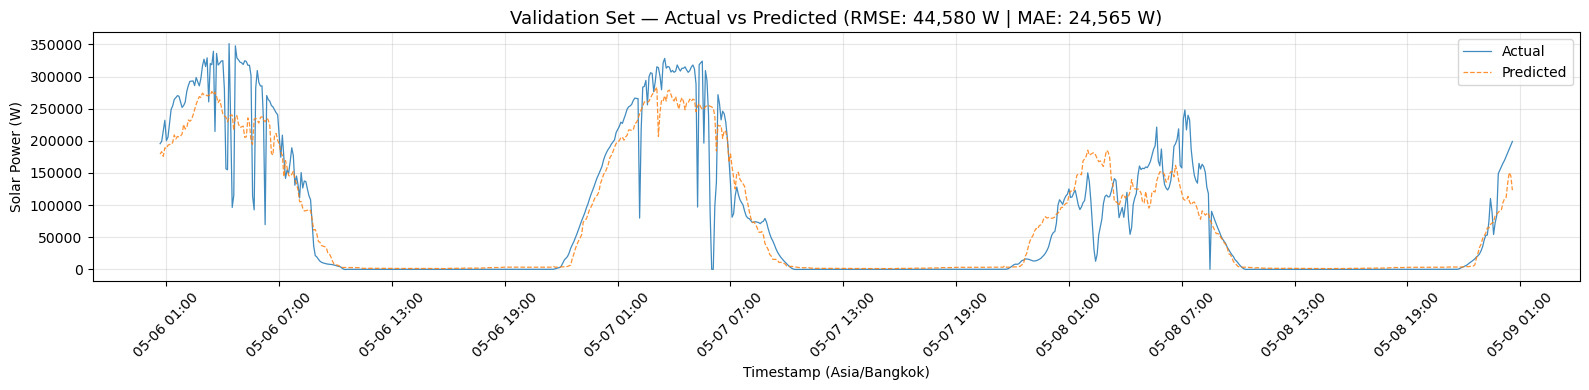

In [23]:
# ─────────────────────────────────────────────────────────────
# CELL 16 — Evaluate Model on Validation Set
# ─────────────────────────────────────────────────────────────

y_pred = model.predict(X_val)

rmse = root_mean_squared_error(y_val, y_pred)
mae  = mean_absolute_error(y_val, y_pred)

print("=" * 40)
print("  Validation Metrics (Solar Power)")
print("=" * 40)
print(f"  RMSE : {rmse:,.2f} W")
print(f"  MAE  : {mae:,.2f} W")
print("=" * 40)

# ── Actual vs Predicted plot ───────────────────────────────────
val_local_ts = df_val.index.tz_convert("Asia/Bangkok")
plot_n = min(len(df_val), 12 * 24 * 3)   # plot up to 3 days of 5-min data

fig, ax = plt.subplots(figsize=(16, 4))
ax.plot(val_local_ts[:plot_n], y_val.values[:plot_n],  label="Actual",    linewidth=0.9, alpha=0.85)
ax.plot(val_local_ts[:plot_n], y_pred[:plot_n],        label="Predicted", linewidth=0.9, alpha=0.85, linestyle="--")
ax.set_title(f"Validation Set — Actual vs Predicted (RMSE: {rmse:,.0f} W | MAE: {mae:,.0f} W)", fontsize=13)
ax.set_xlabel("Timestamp (Asia/Bangkok)")
ax.set_ylabel("Solar Power (W)")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%m-%d %H:%M"))
ax.xaxis.set_major_locator(mdates.HourLocator(interval=6))
plt.xticks(rotation=45)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

   Validation Metrics (Solar Power)
   RMSE : 44,580.03 W
   MAE  : 24,564.99 W


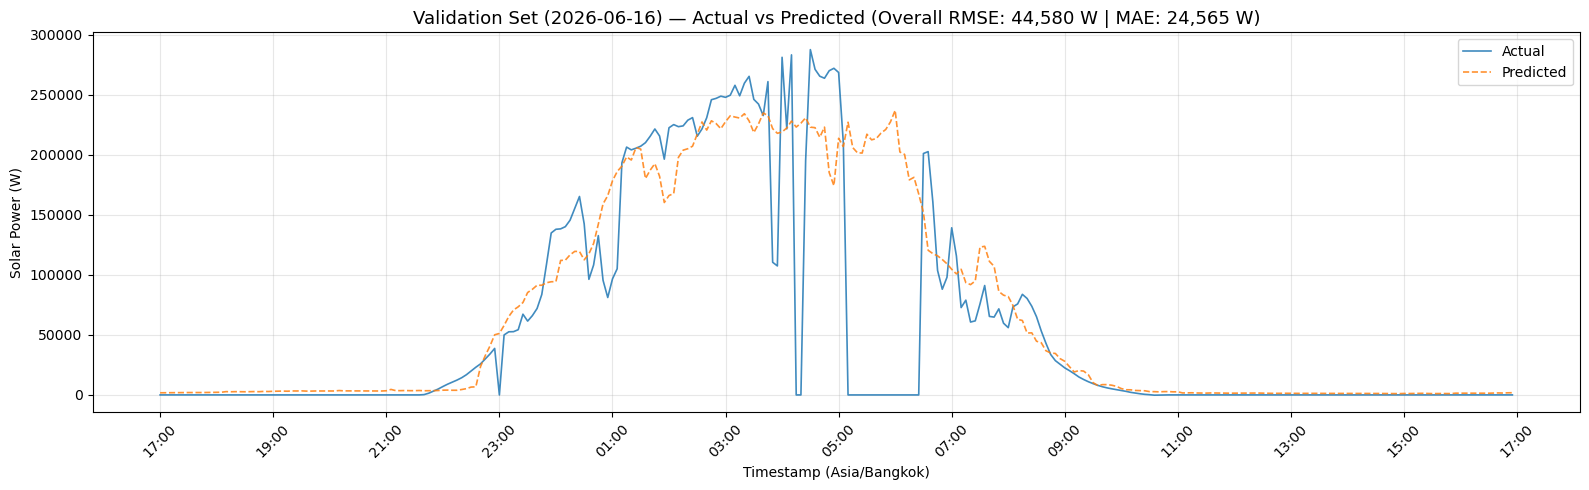

In [24]:
# ─────────────────────────────────────────────────────────────
# CELL 16 — Evaluate Model on Validation Set (Single Day)
# ─────────────────────────────────────────────────────────────

y_pred = model.predict(X_val)

# Calculate global validation metrics
rmse = root_mean_squared_error(y_val, y_pred)
mae  = mean_absolute_error(y_val, y_pred)

print("=" * 40)
print("   Validation Metrics (Solar Power)")
print("=" * 40)
print(f"   RMSE : {rmse:,.2f} W")
print(f"   MAE  : {mae:,.2f} W")
print("=" * 40)

# ── Filter for a single continuous day ───────────────────────
# Ensure index is localized to Bangkok for correct day slicing
val_local_ts = df_val.index.tz_convert("Asia/Bangkok")

# Choose a specific day present in your validation set
target_date = "2026-06-16"
day_mask = val_local_ts.normalize() == target_date

# Extract the continuous slices
ts_day = val_local_ts[day_mask]
y_val_day = y_val.values[day_mask]
y_pred_day = y_pred[day_mask]

# ── Actual vs Predicted plot ───────────────────────────────────
fig, ax = plt.subplots(figsize=(16, 5))

ax.plot(ts_day, y_val_day,  label="Actual",    linewidth=1.2, alpha=0.85)
ax.plot(ts_day, y_pred_day, label="Predicted", linewidth=1.2, alpha=0.85, linestyle="--")

ax.set_title(f"Validation Set ({target_date}) — Actual vs Predicted (Overall RMSE: {rmse:,.0f} W | MAE: {mae:,.0f} W)", fontsize=13)
ax.set_xlabel("Timestamp (Asia/Bangkok)")
ax.set_ylabel("Solar Power (W)")

# Tighter interval spacing since it's just one day
ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
ax.xaxis.set_major_locator(mdates.HourLocator(interval=2))

plt.xticks(rotation=45)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

   Validation Metrics (Solar Power)
   RMSE : 44,580.03 W
   MAE  : 24,564.99 W
📊 Slicing validation set for single continuous day visualization: 2026-06-18


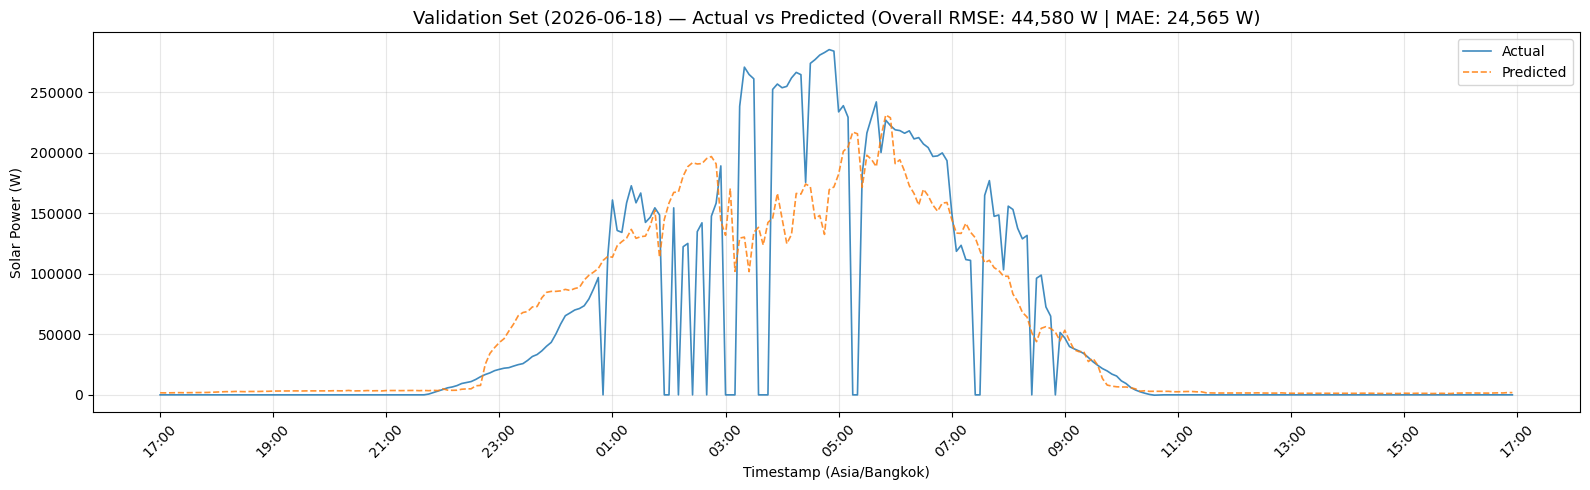

In [25]:
# ─────────────────────────────────────────────────────────────
# CELL 16 — Evaluate Model on Validation Set (Single Day)
# ─────────────────────────────────────────────────────────────

y_pred = model.predict(X_val)

# Calculate global validation metrics
rmse = root_mean_squared_error(y_val, y_pred)
mae  = mean_absolute_error(y_val, y_pred)

print("=" * 40)
print("   Validation Metrics (Solar Power)")
print("=" * 40)
print(f"   RMSE : {rmse:,.2f} W")
print(f"   MAE  : {mae:,.2f} W")
print("=" * 40)

# ── Filter for a single continuous day ───────────────────────
# Ensure index is localized to Bangkok for correct day slicing
val_local_ts = df_val.index.tz_convert("Asia/Bangkok")

# ✅ FIX: Automatically pick a safe date from the validation index instead of hardcoding
target_date = val_local_ts.normalize().unique()[-2].strftime("%Y-%m-%d") # Picks the second-to-last day available
print(f"📊 Slicing validation set for single continuous day visualization: {target_date}")

day_mask = val_local_ts.normalize() == target_date

# Extract the continuous slices
ts_day = val_local_ts[day_mask]
y_val_day = y_val.values[day_mask]
y_pred_day = y_pred[day_mask]

# ── Actual vs Predicted plot ───────────────────────────────────
fig, ax = plt.subplots(figsize=(16, 5))

ax.plot(ts_day, y_val_day,  label="Actual",    linewidth=1.2, alpha=0.85)
ax.plot(ts_day, y_pred_day, label="Predicted", linewidth=1.2, alpha=0.85, linestyle="--")

ax.set_title(f"Validation Set ({target_date}) — Actual vs Predicted (Overall RMSE: {rmse:,.0f} W | MAE: {mae:,.0f} W)", fontsize=13)
ax.set_xlabel("Timestamp (Asia/Bangkok)")
ax.set_ylabel("Solar Power (W)")

# Tighter interval spacing since it's just one day
ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
ax.xaxis.set_major_locator(mdates.HourLocator(interval=2))

plt.xticks(rotation=45)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [26]:
# Create a daytime mask based on the Bangkok index
val_hours = df_val.index.tz_convert("Asia/Bangkok").hour
daylight_mask = (val_hours >= 6) & (val_hours <= 18)

# Calculate RMSE and MAE strictly during sunlit hours
daylight_rmse = root_mean_squared_error(y_val[daylight_mask], y_pred[daylight_mask])
daylight_mae = mean_absolute_error(y_val[daylight_mask], y_pred[daylight_mask])

print(f"☀️ Daylight-Only RMSE : {daylight_rmse:,.2f} W")
print(f"☀️ Daylight-Only MAE  : {daylight_mae:,.2f} W")

☀️ Daylight-Only RMSE : 59,911.02 W
☀️ Daylight-Only MAE  : 40,534.64 W


,feature,importance
0,hour_sin,38.850239
1,ac_power_total,16.210400
2,rolling_mean_6,7.496213
3,rolling_mean_24,6.676331
4,hour_cos,6.305253
5,lag_288,5.699985
6,rolling_mean_12,4.936723
7,rolling_std_6,2.977046
8,solar_irradiance_forecast_1h,2.958957
9,day_of_week,2.256876


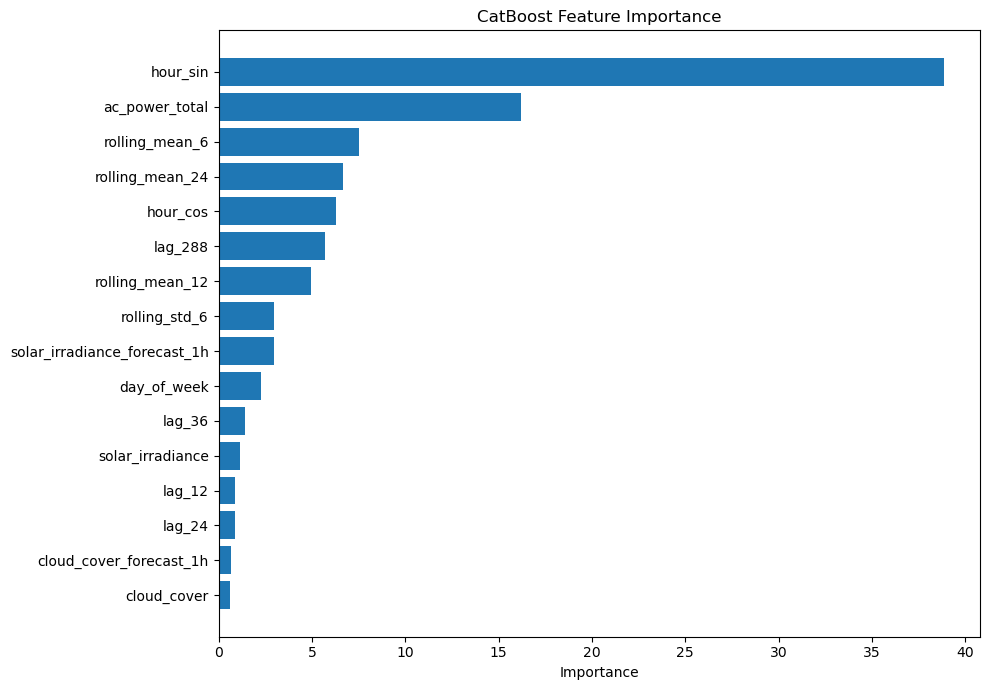

In [27]:
# ─────────────────────────────────────────────────────────────
# CELL 17 — Feature Importance
# ─────────────────────────────────────────────────────────────

importance_df = pd.DataFrame({
    "feature": FEATURES,
    "importance": model.get_feature_importance()
})

importance_df = importance_df.sort_values(
    "importance",
    ascending=False
).reset_index(drop=True)

display(importance_df)

plt.figure(figsize=(10, 7))
plt.barh(
    importance_df["feature"][:18][::-1],
    importance_df["importance"][:18][::-1]
)
plt.title("CatBoost Feature Importance")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()